# Tweet sentiment over time — Donald Trump vs. Elon Musk

This notebook reproduces the 6-month-averaged tweet-positivity time series. It
is **self-contained**: it downloads everything it needs and produces the graph.

What it does:
1. builds a sentiment model (TF-IDF + Logistic Regression) trained on **Sentiment140** — or loads the saved full-data model if present;
2. downloads the **public tweet archives** for @realDonaldTrump and @elonmusk;
3. aligns both to the same time window and **cuts at Nov 7 2017** (when Twitter went from 140 to 280 characters), so the tweets stay in the same short-tweet regime the model was trained on;
4. plots mean positivity (the model's P(positive)) averaged per 6 months.

**Data sources (auto-downloaded below; links here as a fallback):**
- Sentiment140 (training data): https://huggingface.co/datasets/stanfordnlp/sentiment140 — we read the Hub's auto-converted Parquet of the 1.6M train split.
- Trump tweets: https://github.com/bpb27/trump_tweet_data_archive (`condensed_2009.json.zip` … `condensed_2017.json.zip`).
- Musk tweets: https://github.com/MohrezSheikh/Elon-Musk-Tweets (`ElonMusk'sTweets.csv`).

> ⚠️ **Caveat:** the model is trained on 2009 personal tweets labelled by emoticons; political/business tweets are out-of-distribution and it leans positive on promotional/neutral text. Read the *relative trend over time*, not the absolute level.

## Install dependencies

In [ ]:
%pip install -q datasets scikit-learn pandas matplotlib huggingface_hub

## Imports and configuration

In [2]:
import os, re, io, json, html, glob, zipfile, pickle, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline, FeatureUnion

SEED = 42
CUT = pd.Timestamp('2017-11-07', tz='UTC')   # 140 -> 280 character change
N_TRAIN = 400_000                            # balanced training size if we train here
MODEL_PATH = 'models/classical_full.pkl'     # exact original model, if available locally

def clean_tweet(text):
    text = html.unescape(str(text))                 # &amp; -> &, etc.
    text = re.sub(r'https?://\S+', '', text)        # strip URLs
    text = re.sub(r'@\w+', '@user', text)           # @mentions -> @user
    text = re.sub(r'\s+', ' ', text).strip()        # normalize whitespace
    return text

## Step 1 — the sentiment model

If the saved full-data model (`models/classical_full.pkl`, trained on 1.39M tweets) is present we load it for an exact reproduction; otherwise we train a TF-IDF + Logistic Regression model on a balanced Sentiment140 subsample. (Raise `N_TRAIN` toward the full 1.6M for a closer match to the original.)

In [3]:
if os.path.exists(MODEL_PATH):
    with open(MODEL_PATH, 'rb') as f:
        clf = pickle.load(f)
    print('Loaded saved model:', MODEL_PATH)
else:
    from huggingface_hub import hf_hub_download
    print('Downloading Sentiment140 (1.6M) and training a model...')
    path = hf_hub_download('stanfordnlp/sentiment140', 'sentiment140/train/0000.parquet',
                           repo_type='dataset', revision='refs/convert/parquet')
    df = pd.read_parquet(path)[['text', 'sentiment']].rename(columns={'sentiment': 'label'})
    df = df[df.label.isin([0, 4])].copy(); df['label'] = (df.label == 4).astype(int)
    per = N_TRAIN // 2
    rng = np.random.RandomState(SEED)
    parts = []
    for lbl in (0, 1):
        sub = df[df.label == lbl]
        parts.append(sub.iloc[rng.permutation(len(sub))[:per]])
    train = pd.concat(parts).sample(frac=1.0, random_state=SEED)
    train['text'] = train['text'].map(clean_tweet)
    clf = Pipeline([('feats', FeatureUnion([
        ('w', TfidfVectorizer(analyzer='word', ngram_range=(1, 2), min_df=2,
                              sublinear_tf=True, max_features=200_000)),
        ('c', TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5), min_df=2,
                              sublinear_tf=True, max_features=200_000)),
    ])), ('lr', LogisticRegression(C=1.0, max_iter=1000))])
    clf.fit(train.text, train.label)
    print(f'Trained on {len(train):,} tweets')

Loaded saved model: models/classical_full.pkl


## Step 2 — download Donald Trump's tweets

Source: [bpb27/trump_tweet_data_archive](https://github.com/bpb27/trump_tweet_data_archive) — condensed JSON, one file per year. We use 2009–2017 and exclude retweets.

In [4]:
trump_rows = []
for y in range(2009, 2018):
    url = f'https://raw.githubusercontent.com/bpb27/trump_tweet_data_archive/master/condensed_{y}.json.zip'
    raw = urllib.request.urlopen(url).read()
    z = zipfile.ZipFile(io.BytesIO(raw))
    for t in json.loads(z.read(z.namelist()[0])):
        if not t.get('is_retweet', False):
            trump_rows.append((t['created_at'], t['text']))
trump = pd.DataFrame(trump_rows, columns=['created_at', 'text'])
trump['dt'] = pd.to_datetime(trump['created_at'], format='%a %b %d %H:%M:%S %z %Y', utc=True)
trump['author'] = 'Trump'
print('Trump tweets (non-RT):', len(trump))

Trump tweets (non-RT): 32299


## Step 3 — download Elon Musk's tweets

Source: [MohrezSheikh/Elon-Musk-Tweets](https://github.com/MohrezSheikh/Elon-Musk-Tweets).

In [5]:
MUSK_URL = ('https://raw.githubusercontent.com/MohrezSheikh/Elon-Musk-Tweets/'
            'master/ElonMusk%27sTweets.csv')
musk = pd.read_csv(MUSK_URL)
musk['dt'] = pd.to_datetime(musk['created_at'], utc=True)
musk = musk.rename(columns={'tweet': 'text'})[['text', 'dt']]
musk['author'] = 'Musk'
print('Musk tweets:', len(musk))

Musk tweets: 16490


## Step 4 — clean, align the window, and score

Both authors are restricted to the **same window** — from the later of their two first-tweet dates up to the Nov 2017 character-limit change — then each tweet is cleaned and scored by the model.

In [6]:
df = pd.concat([trump[['author', 'dt', 'text']], musk[['author', 'dt', 'text']]],
               ignore_index=True)
df['clean'] = df.text.map(clean_tweet)
df = df[df.clean.str.len() > 0]

start = max(df[df.author == 'Trump'].dt.min(), df[df.author == 'Musk'].dt.min())
df = df[(df.dt >= start) & (df.dt < CUT)].copy()
df['p_pos'] = clf.predict_proba(df.clean.tolist())[:, 1]

print(f'Window: {start.date()} -> {CUT.date()}')
summary = {}
for a in ['Trump', 'Musk']:
    sub = df[df.author == a]
    summary[a] = {'n': len(sub), 'pct': round((sub.p_pos > 0.5).mean() * 100, 1)}
    print(f"  {a}: n={len(sub):>6}  positive={summary[a]['pct']}%")

Window: 2010-06-04 -> 2017-11-07
  Trump: n= 31834  positive=75.8%
  Musk: n=  3021  positive=76.2%


## Step 5 — the time series graph

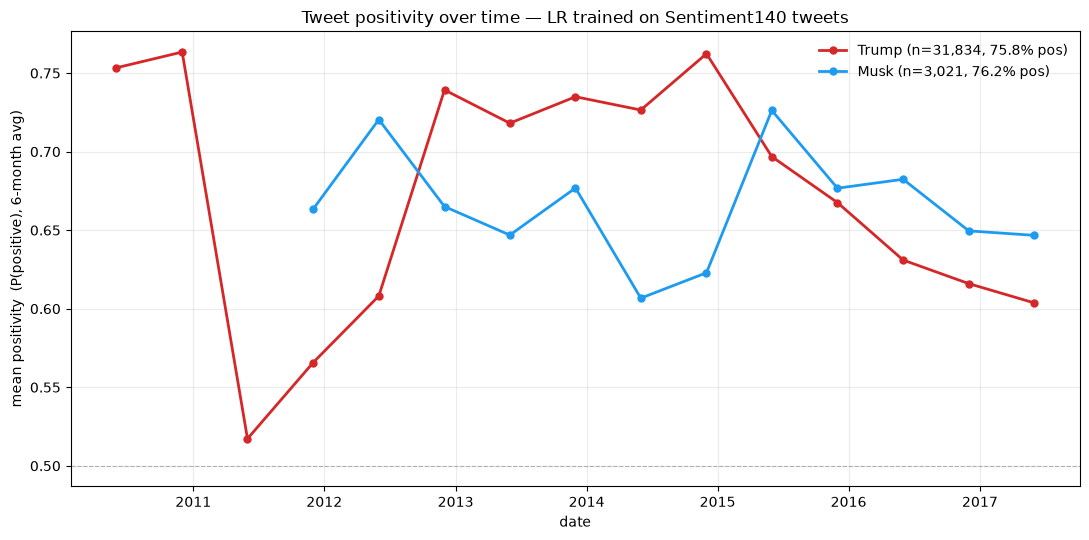

In [7]:
fig, ax = plt.subplots(figsize=(11, 5.5))
colors = {'Trump': '#d62728', 'Musk': '#1d9bf0'}
for a in ['Trump', 'Musk']:
    s = (df[df.author == a].set_index('dt').sort_index()
         .resample('6MS')['p_pos'].agg(['mean', 'count']))
    s = s[s['count'] >= 15]                       # drop near-empty bins
    ax.plot(s.index, s['mean'], 'o-', color=colors[a], lw=2, ms=5,
            label=f"{a} (n={summary[a]['n']:,}, {summary[a]['pct']}% pos)")
ax.axhline(0.5, color='#888', lw=0.8, ls='--', alpha=0.6)
ax.set_ylabel('mean positivity  (P(positive), 6-month avg)')
ax.set_xlabel('date')
ax.set_title('Tweet positivity over time — LR trained on Sentiment140 tweets')
ax.grid(True, alpha=0.25)
ax.legend(loc='best', frameon=False)
fig.tight_layout()
plt.show()

## Notes

- **Trump** holds high positivity through 2014–early 2015, then declines steadily across the 2015–17 campaign/presidency window; **Musk** is steadier, drifting down gently. Both sit around ~76% positive overall.
- The original graph used the model trained on the full **1.39M** Sentiment140 tweets; training here on a subsample gives a near-identical curve (the 6-month trend is driven by the tweets, not the exact model).
- Domain-shift caveat (see top): the absolute positivity level is inflated on out-of-domain text — the meaningful signal is the relative trend over time.